# PREGUNTA 12: Ejercicio Práctico 2 Valuación de opciones exóticas con Monte Carlo

# Eduardo Veytia Hernández

### 1. Elige un activo y define parámetros: S, K, T, σ y r. Justifica brevemente cada uno.
Elegí GOOG, lo usé en el ejercicio anterior.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

In [3]:
S0 = 385.46    # Precio spot actual en USD
K = 390.00     # Precio de ejercicio (Strike), ligeramente OTM
T = 1.0        # Tiempo al vencimiento en años (1 año)
r = 0.0379     # Tasa libre de riesgo (3.79%, rendimiento del Tesoro de EE. UU. a 1 año)
sigma = 0.3011 # Volatilidad implícita anualizada (30.11%)
B = 450.00     # Barrera Up-and-out, nivel definido razonablemente por encima del spot
n_sims  = 50_000
n_steps = 126
dt      = T / n_steps

np.random.seed(42)

### 2. Implementa la valuación por Monte Carlo (al menos 50,000 trayectorias) de las siguientes cuatro opciones:
- Call europea estándar (referencia).
- Put europea estándar (referencia).
- Opción asiática call (payoff basado en el promedio aritmético del precio a lo largo de la trayectoria).
- Opción call con barrera up-and-out (la opción se cancela si el precio supera una barrera B que tú defines; justifica tu elección de B).

In [4]:
Z = np.random.standard_normal((n_sims, n_steps))
log_returns = (r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z
log_paths   = np.log(S0) + np.cumsum(log_returns, axis=1)
S_paths     = np.exp(log_paths)
S_paths     = np.hstack([np.full((n_sims,1), S0), S_paths])

print(f'Shape de trayectorias: {S_paths.shape}')
print(f'S_T media simulada:   {S_paths[:,-1].mean():.2f}')
print(f'S_T media teórica:    {S0*np.exp(r*T):.2f}')

Shape de trayectorias: (50000, 127)
S_T media simulada:   399.92
S_T media teórica:    400.35


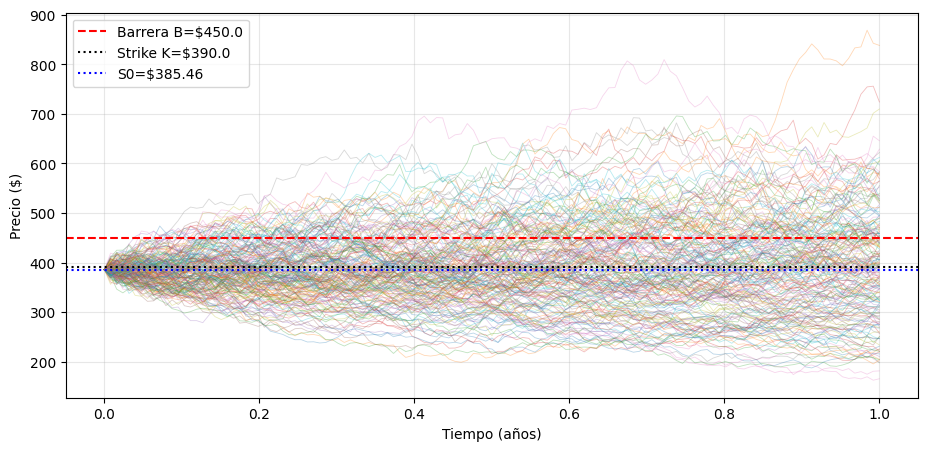

In [7]:
plt.figure(figsize=(11,5))
plt.plot(np.linspace(0, T, n_steps+1), S_paths[:200].T, alpha=0.3, linewidth=0.6)
plt.axhline(B, color='red',   linestyle='--', label=f'Barrera B=${B}')
plt.axhline(K, color='black', linestyle=':',  label=f'Strike K=${K}')
plt.axhline(S0, color='blue', linestyle=':',  label=f'S0=${S0}')
plt.xlabel('Tiempo (años)')
plt.ylabel('Precio ($)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### 3. Valuación de las cuatro opciones (12 pts, 3 por opción): payoff correcto para cada tipo, descuento correcto al presente

In [8]:
ST       = S_paths[:, -1]
S_avg    = S_paths[:, 1:].mean(axis=1)
max_path = S_paths.max(axis=1)

payoff_call  = np.maximum(ST - K, 0)
payoff_put   = np.maximum(K - ST, 0)
payoff_asian = np.maximum(S_avg - K, 0)

knocked_out = max_path >= B
payoff_uo   = np.where(knocked_out, 0, np.maximum(ST - K, 0))

print(f'Porcentaje de trayectorias knocked-out: {knocked_out.mean()*100:.2f}%')

Porcentaje de trayectorias knocked-out: 56.26%


In [9]:
discount = np.exp(-r*T)

price_call  = discount * payoff_call.mean()
price_put   = discount * payoff_put.mean()
price_asian = discount * payoff_asian.mean()
price_uo    = discount * payoff_uo.mean()

se_call  = discount * payoff_call.std()  / np.sqrt(n_sims)
se_put   = discount * payoff_put.std()   / np.sqrt(n_sims)
se_asian = discount * payoff_asian.std() / np.sqrt(n_sims)
se_uo    = discount * payoff_uo.std()    / np.sqrt(n_sims)

print(f'Call europea:    ${price_call:.4f}  (SE ±{se_call:.4f})')
print(f'Put europea:     ${price_put:.4f}  (SE ±{se_put:.4f})')
print(f'Asiática call:   ${price_asian:.4f}  (SE ±{se_asian:.4f})')
print(f'Up-and-out call: ${price_uo:.4f}  (SE ±{se_uo:.4f})')

Call europea:    $50.2958  (SE ±0.3748)
Put europea:     $40.7409  (SE ±0.2388)
Asiática call:   $27.5799  (SE ±0.2008)
Up-and-out call: $1.0583  (SE ±0.0253)


### 4. Tabla comparativa con comentario: tabla clara con los cuatro precios, comentario correcto sobre por qué las exóticas son más baratas.

In [10]:
tabla = pd.DataFrame({
    'Opción':         ['Call europea', 'Put europea', 'Asiática call', 'Up-and-out call'],
    'Precio MC ($)':  [price_call,    price_put,     price_asian,     price_uo],
    'SE ($)':         [se_call,       se_put,        se_asian,        se_uo],
    'Payoff > 0 (%)': [(payoff_call>0).mean()*100, (payoff_put>0).mean()*100,
                       (payoff_asian>0).mean()*100, (payoff_uo>0).mean()*100],
    'Payoff medio ($)': [payoff_call.mean(), payoff_put.mean(), payoff_asian.mean(), payoff_uo.mean()],
    'vs Call EU (%)': [100.0, np.nan, price_asian/price_call*100, price_uo/price_call*100],
}).round(4)
tabla

,Opción,Precio MC ($),SE ($),Payoff > 0 (%),Payoff medio ($),vs Call EU (%)
0,Call europea,50.2958,0.3748,47.492,52.2386,100.0000
1,Put europea,40.7409,0.2388,52.508,42.3147,NaN
2,Asiática call,27.5799,0.2008,47.274,28.6452,54.8353
3,Up-and-out call,1.0583,0.0253,5.002,1.0992,2.1042


### 5. Gráfica de distribuciones de payoff (4 pts): cuatro subplots en una figura, claros y bien etiquetados, diferencias visualmente evidentes.

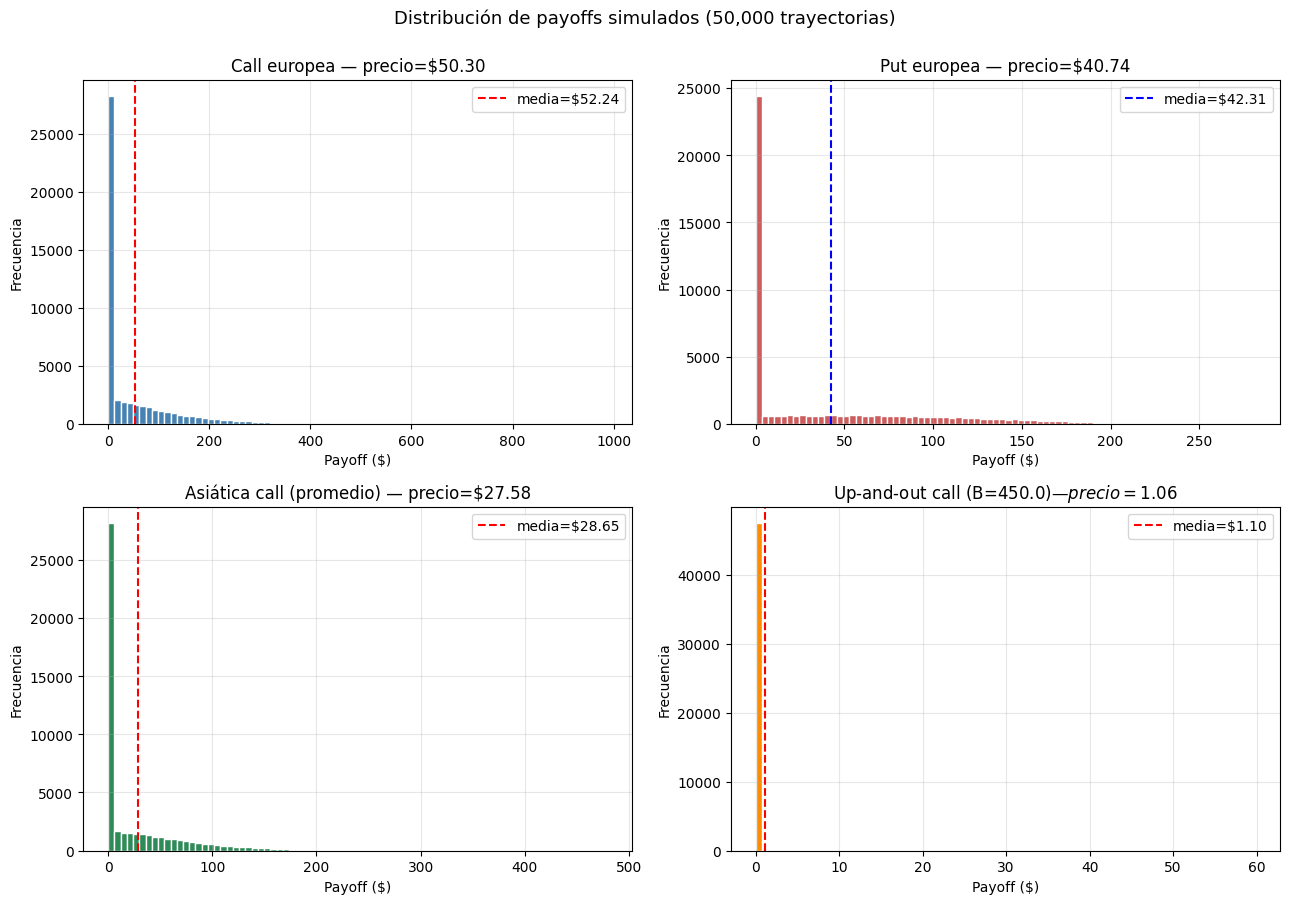

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

ax = axes[0,0]
ax.hist(payoff_call, bins=80, color='steelblue', edgecolor='white')
ax.axvline(payoff_call.mean(), color='red', linestyle='--', label=f'media=${payoff_call.mean():.2f}')
ax.set_title(f'Call europea — precio=${price_call:.2f}')
ax.set_xlabel('Payoff ($)'); ax.set_ylabel('Frecuencia')
ax.legend(); ax.grid(alpha=0.3)

ax = axes[0,1]
ax.hist(payoff_put, bins=80, color='indianred', edgecolor='white')
ax.axvline(payoff_put.mean(), color='blue', linestyle='--', label=f'media=${payoff_put.mean():.2f}')
ax.set_title(f'Put europea — precio=${price_put:.2f}')
ax.set_xlabel('Payoff ($)'); ax.set_ylabel('Frecuencia')
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1,0]
ax.hist(payoff_asian, bins=80, color='seagreen', edgecolor='white')
ax.axvline(payoff_asian.mean(), color='red', linestyle='--', label=f'media=${payoff_asian.mean():.2f}')
ax.set_title(f'Asiática call (promedio) — precio=${price_asian:.2f}')
ax.set_xlabel('Payoff ($)'); ax.set_ylabel('Frecuencia')
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1,1]
ax.hist(payoff_uo, bins=80, color='darkorange', edgecolor='white')
ax.axvline(payoff_uo.mean(), color='red', linestyle='--', label=f'media=${payoff_uo.mean():.2f}')
ax.set_title(f'Up-and-out call (B=${B}) — precio=${price_uo:.2f}')
ax.set_xlabel('Payoff ($)'); ax.set_ylabel('Frecuencia')
ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('Distribución de payoffs simulados (50,000 trayectorias)', fontsize=13, y=1.00)
plt.tight_layout()
plt.show()

### 6. En markdown: explica con tus propias palabras qué característica del payoff de cada opción exótica justifica que su precio sea diferente al de la europea estándar. Usa los resultados de tu simulación como evidencia.


El diseño del payoff determina el precio de la opción al limitar sus ganancias potenciales. En comparación con una Call europea estándar:

Asiática: Promediar el precio del activo suaviza la volatilidad y recorta los picos de ganancias extremas. Al tener un pago esperado menor, la opción es más barata.

Up-and-out (Efecto Barrera): Introducir un límite de desactivación elimina las trayectorias de mayor rentabilidad. Como el comprador asume un altísimo riesgo de que la opción muera si el mercado sube demasiado, su precio es más bajo.

Cualquier restricción contractual en el payoff reduce la exposición a ganancias extraordinarias, y nos ofrecen una prima más baja.